# Salary Prediction

Import Libraries

In [2]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Load dataset

In [5]:
df = pd.read_csv("Salary_Data.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

First 5 rows:
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
None


In [6]:
print(df.columns)

Index(['YearsExperience', 'Salary'], dtype='object')


## Handle Missing Values

In [6]:
df = df.fillna(df.mean(numeric_only=True))

## Feature Selection

In [7]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [8]:
# (Assuming columns: experience, test_score, interview_score, salary)
X = df.drop("Salary", axis=1)
y = df["Salary"]

## Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2204108
)

## Train Multiple Linear Regression

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Predictions

In [10]:
y_pred = model.predict(X_test)

## Evaluation

In [11]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nMultiple Feature Model:")
print("RMSE:", rmse)
print("R² Score:", r2)


Multiple Feature Model:
RMSE: 5163.190602918611
R² Score: 0.9704534798533588


## Single Feature Model

In [13]:
X_single = df[["YearsExperience"]]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_single, y, test_size=0.2, random_state=42
)

model_single = LinearRegression()
model_single.fit(X_train_s, y_train_s)

y_pred_s = model_single.predict(X_test_s)

rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
r2_s = r2_score(y_test_s, y_pred_s)

print("\nSingle Feature Model:")
print("RMSE:", rmse_s)
print("R² Score:", r2_s)


Single Feature Model:
RMSE: 7059.04362190151
R² Score: 0.9024461774180497


## Compare

In [14]:
print("\nComparison:")
print("Multiple Features R²:", r2)
print("Single Feature R²:", r2_s)


Comparison:
Multiple Features R²: 0.9704534798533588
Single Feature R²: 0.9024461774180497


## Save Best Model

In [15]:
pickle.dump(model, open("salary_model.pkl", "wb"))

## Example Prediction

In [18]:
sample = pd.DataFrame([[5]], columns=["YearsExperience"])
prediction = model.predict(sample)

print("Predicted Salary:", prediction[0])

Predicted Salary: 72672.78091701645


## Scatter Plot + Regression Line

In [23]:
sns.set(style="whitegrid")

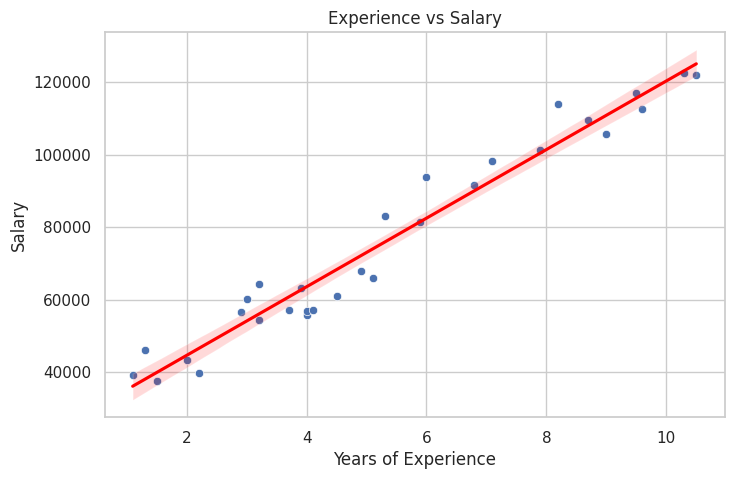

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["YearsExperience"], y=df["Salary"])

# Regression line
sns.regplot(x=df["YearsExperience"], y=df["Salary"], scatter=False, color="red")

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

## Actual vs Predicted Plot

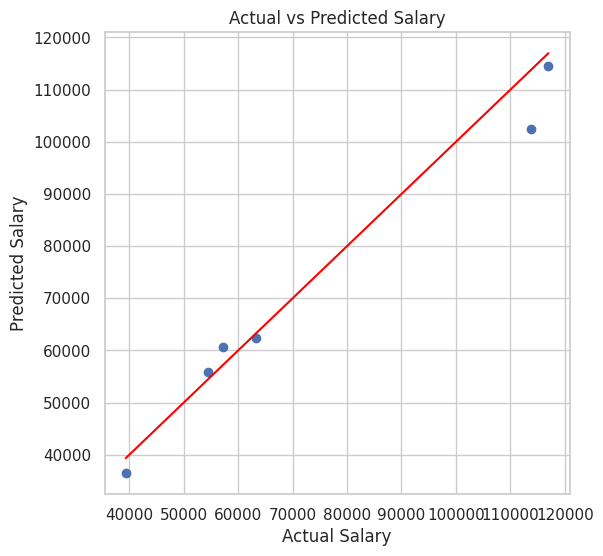

In [25]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')

plt.show()

## Residual Plot

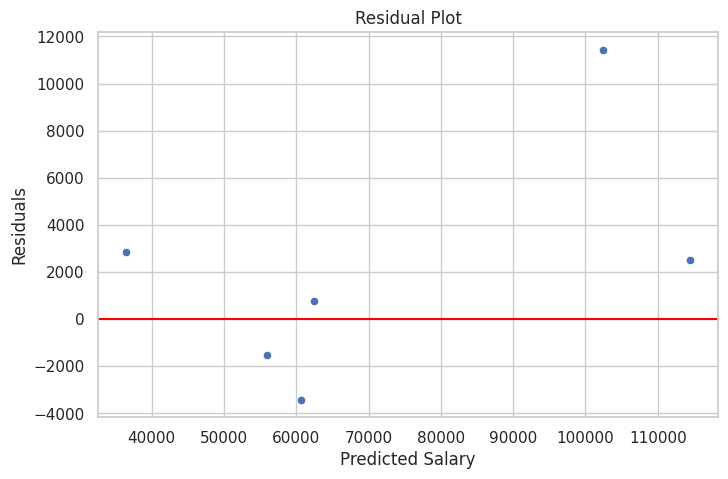

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color='red')
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Distribution Plot

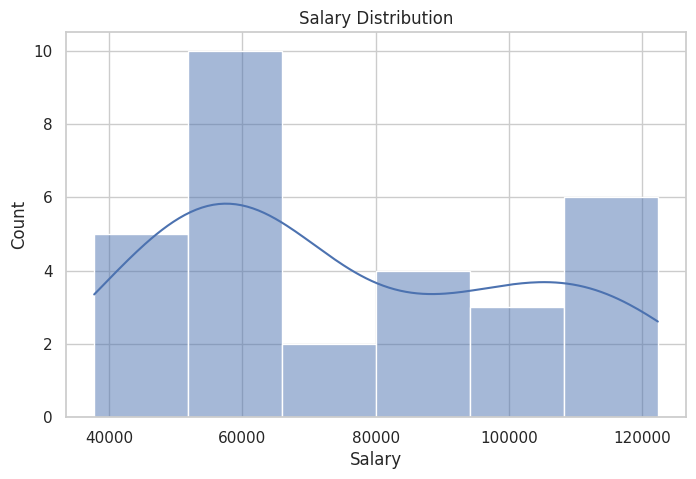

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary"], kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.show()